Defining imports, fixed potentials and some useful functions to integrate particles in MW--LMC potential

In [2]:
import agama
import numpy as np
import scipy.integrate
import gala.potential as gp
import gala.units as gu
import astropy.units as u
import os

import scipy.optimize as opt
from scipy.special import erf 

import matplotlib, matplotlib.pyplot as plt
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"
# plt.style.use('my_standard.mplstyle')

mass_unit = 232500 
agama.setUnits(length=1, velocity=1 , mass=mass_unit) 
usys = gu.UnitSystem(u.kpc, 977.79222168*u.Myr, mass_unit*u.Msun, u.radian, u.km/u.s)

In [3]:
seed, Tbegin, Tfinal, Tstep, Nstars = 1, -2, 0, 0.001, 20000 # examples parameter for the integration

# Setting the random seed for this batch of simulation
rng = np.random.default_rng(seed=seed)
agama.setRandomSeed(seed) # can't use seed=0 so hence seed += 1 above
cleanup= True

rho_crit = 127.0  # Msun/kpc^3, approximate critical density at z=0

In [4]:
potbulge = dict(Type='Spheroid', mass=1.2e10/mass_unit, 
            scaleRadius=0.2, 
            outerCutoffRadius=1.8, 
            gamma=0.0, 
            beta=1.8)
potdisk  = dict(Type='Disk', SurfaceDensity=3803.5, 
                scaleRadius=3.0, 
                scaleHeight=-0.4)

potbary = agama.Potential(potbulge, potdisk)

In [5]:
def simMWLMC(Mmw, c, Mlmc, almc, LMCfc0, log_sdf):
    '''
    compute the past trajectories of MW and LMC under mutual gravitational acceleration,
    and return the combined time-dependent MW-centered potential
    (including acceleration from the non-inertial reference frame) and the LMC trajectory
    Parameters:
    Mmw - M200 of the NFW Milky Way model [Msun/mass_units]
    c - c200 of the NFW Milky Way model [dimensionless]
    Mlmc - Total mass of the Hernquist LMC model [Msun/mass_units]
    almc - Scale radius of the Hernquist LMC model [kpc]
    LMCfc0 - Array shape (6,) of the LMC present-day positions [kpc] and velocities [km/s]
    log_sdf - Scalar the modulates the strength of the Chandrasekhar dynamical friction [dimensionless]

    Returns:
    potlmc - Potential of the LMC with moving centre [agama.Potential object]
    potacc - Potential contribution due to the MW reflex motion [agama.Potential object]
    trajlmc - LMC trajectory in the Galactocentric MW frame [kpc, km/s]
    trajmw - MW trajectory in the inertial/box frame [kpc, km/s]
    '''

    gala_pothalo = gp.NFWPotential.from_M200_c(M200=Mmw*mass_unit*u.Msun,
                                               c=c, 
                                               rho_c = rho_crit*(u.Msun / u.kpc**3), 
                                               units=usys)
    pothalo = gala_pothalo.as_interop("agama")

    potbulge = dict(Type='Spheroid', mass=1.2e10/mass_unit, 
                scaleRadius=0.2, 
                outerCutoffRadius=1.8, 
                gamma=0.0, 
                beta=1.8)
    potdisk  = dict(Type='Disk', SurfaceDensity=3803.5, 
                    scaleRadius=3.0, 
                    scaleHeight=-0.4)
    potbary  = agama.Potential(potbulge, potdisk)
    
    potmw = agama.Potential(pothalo, potbary) # variable MW halo mass, constant disk and bulge profiles

    potlmc = agama.Potential(type='Dehnen', 
                             mass = Mlmc, 
                             scaleRadius = almc, 
                             gamma = 1) # Hernquist when gamma=1
    couLog = np.log(100 / almc) # taking a fixed value for each simulation ~1-2. log_sdf modulates this anyway.

    def difeq(t, vars):
        x0=vars[0:3]  # MW pos
        v0=vars[3:6]  # MW vel
        x1=vars[6:9]  # LMC pos
        v1=vars[9:12] # LMC vel
        dx=x1-x0
        dr=sum(dx**2)**0.5
        f0=potlmc.force(-dx)
        f1=potmw.force(dx)

        # Adding a Chandrasekhar prescription for DF
        rsep  = np.linalg.norm(dx)
        vmag_lmc = np.linalg.norm(v1)
        rho_mw = potmw.density(x1)
        sigma = 120.0 # from dillamore+23 and vasiliev+21 for MW (apparently insensitive)
        X = vmag_lmc / (sigma * 2**.5)
        drag = -(4*np.pi*rho_mw*couLog*Mlmc* (erf(X) - (2*X*np.exp(-X**2))/np.pi**.5 ) ) / vmag_lmc**3
        f_df_lmc = v1 * drag * 10**log_sdf
        
        # no scaling of LMC mass required as explicity stated in drag term.
        f1[0]+= f_df_lmc[0] 
        f1[1]+= f_df_lmc[1]
        f1[2]+= f_df_lmc[2]
        return np.hstack((v0, f0, v1, f1))

    tgrid = np.linspace(Tbegin, Tfinal, round((Tfinal-Tbegin)/Tstep)+1)
    ic = np.hstack((np.zeros(6), LMCfc0))
    sol = scipy.integrate.solve_ivp(difeq, (Tfinal, Tbegin), ic, t_eval=tgrid[::-1], max_step=Tstep, rtol=1e-12,
        method='LSODA').y.T[::-1]
    rr=np.sum((sol[:,6:9]-sol[:,0:3])**2, axis=1)**0.5
    vr=np.sum((sol[:,6:9]-sol[:,0:3]) * (sol[:,9:12]-sol[:,3:6]), axis=1) / rr

    if not cleanup:
        tgrid = np.linspace(Tbegin, Tfinal+0.125, round((Tfinal+0.125-Tbegin)/Tstep)+1)
        sol = scipy.integrate.solve_ivp(difeq, (Tbegin, Tfinal+0.125), sol[0], t_eval=tgrid, max_step=Tstep, rtol=1e-12,
            method='LSODA').y.T
   
    mwx = agama.Spline(tgrid, sol[:,0], der=sol[:,3])
    mwy = agama.Spline(tgrid, sol[:,1], der=sol[:,4])
    mwz = agama.Spline(tgrid, sol[:,2], der=sol[:,5])
    
    trajmw = np.column_stack((tgrid, sol[:,0:6]))
    trajmw[:, 1:4] -= trajmw[:, 1:4][0] #first subtract the initial position: x0
    trajmw[:, 1:4] -= (trajmw[:, 4:][0] * (trajmw.T[0][:,np.newaxis] - Tbegin)) #now subtract the constant drift velocity (linear term): V0 * (t - Tbegin)
    trajmw[:, 4:] -= trajmw[:, 4:][0] #subtract the initial velocity: v0
    
    trajlmc = np.column_stack((tgrid, sol[:,6:12]-sol[:,0:6]))  # LMC trajectory in the MW-centered reference frame

    accfile = np.column_stack((tgrid, -mwx(tgrid,2), -mwy(tgrid,2), -mwz(tgrid,2)))
    potacc = agama.Potential(type='UniformAcceleration', file=accfile)
    potlmc = agama.Potential(center=trajlmc, 
                             type='Dehnen',
                              mass = Mlmc ,
                              scaleRadius = almc,
                              gamma = 1)

    potmwlmc = agama.Potential(potmw, potlmc, potacc)
    
    return potmw, potmwlmc

Integrating some stellar halo particles in a MW--LMC potential using reasonable values

In [6]:
Mmw, cmw = 15e11, 10 # rough MW virial mass in 10^11Msun and concentration
lmc_fc = np.array([-0.6, -41.3, -27.1, 
                      -63.9, -213.8, 206.6])
Mlmc, almc = 18e10, 15 # rough LMC total mass in 10^10 Msun and scale radius in kpc
log_sdf = 0.0 # setting to chandrasekhar
dehnen_scale, beta0, outer_slope = 12.5, 0.6, 4 # setting the stellar halo density parameters

In [7]:
potmw, potmwlmc = simMWLMC(Mmw / mass_unit, cmw, 
                     Mlmc / mass_unit, almc, lmc_fc,
                     log_sdf)

/home/rene/projects/masters_thesis/masters-thesis/.venv/lib/python3.14/site-packages/agama/py/pygama.py:21: RuntimeWarning: setUnits() called after creating instances of Potential and other classes may lead to incorrect scaling of input/output data in their methods
  return _setUnits(**args)  # call the setUnits(...) function from the C++ extension module



In [8]:
dens = agama.Density(type="Spheroid", 
                    scaleRadius=dehnen_scale,
                    # alpha=1., #transition steepness
                    beta=outer_slope, #outer slope 
                    gamma=1, #inner slope 
                    outerCutoffRadius=300 #kpc (something reasonable to taper stellar halo for finite mass)
                    )

df = agama.DistributionFunction(type="QuasiSpherical", 
                                potential=potmw, 
                                density = dens,
                                beta0 = beta0,
                                r_a = np.inf)

gm = agama.GalaxyModel(potmw, df)

In [9]:
w0 = gm.sample(Nstars)[0]

ts, wf = agama.orbit(ic=w0, 
                 potential=potmwlmc, 
                 timestart=Tbegin, 
                 time=np.abs(Tbegin), 
                 trajsize=1).T 

wf_stack = np.vstack(wf, dtype=np.float32) 

20000 orbits complete (7151 orbits/s)           


Compare the intial and final (radial) distriubtions of particles

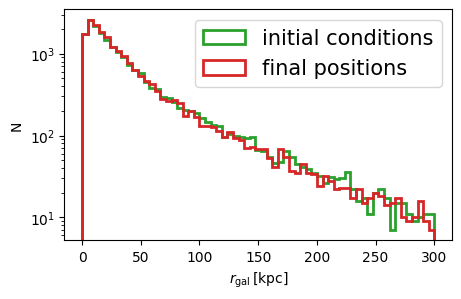

In [10]:
plt.figure(figsize=(5,3))

bins = np.linspace(0, 300, 64)
_ = plt.hist(
    np.linalg.norm(w0[:,:3], axis=1),
    bins=bins,
    histtype="step",
    color="tab:green",
    lw=2,
    label="initial conditions",
)
_ = plt.hist(
    np.linalg.norm(wf_stack[:,:3], axis=1),
    bins=bins,
    histtype="step",
    color="tab:red",
    lw=2,
    label="final positions",
)
plt.legend(loc="best", fontsize=15)

plt.xlabel(r'$r_{\rm gal}\,[\rm kpc]$')

plt.yscale('log')
plt.ylabel('N')

plt.show()